# EDA 1 - Daily LME Aluminium and Exogenous Inventory

Notebook ini adalah EDA utama tahap awal untuk proyek INALUM.

Tujuan notebook:
- memahami inventaris dataset yang tersedia
- mengaudit kualitas dasar target dan exogenous
- melihat perilaku awal target `daily`
- menyusun shortlist awal kandidat regressor untuk eksperimen `Prophet + regressors`

Fokus notebook ini masih pada `pemahaman data`, belum masuk ke training model.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with 'data' and 'notebooks' folders.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
EXOG_DIR = DATA_DIR / "Exogenous"

def load_csv(path):
    df = pd.read_csv(path)
    date_col = next((col for col in ["startdatetime", "datestamp", "date"] if col in df.columns), None)
    if date_col is not None:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    return df

def infer_date_col(df):
    return next((col for col in ["startdatetime", "datestamp", "date"] if col in df.columns), None)

def infer_frequency(date_series):
    values = pd.Series(date_series).dropna().drop_duplicates().sort_values()
    if len(values) < 3:
        return "unknown"
    diffs = values.diff().dropna().dt.days
    if diffs.empty:
        return "unknown"
    median_diff = diffs.median()
    if median_diff <= 1.5:
        return "daily-ish"
    if median_diff <= 8:
        return "weekly-ish"
    if median_diff <= 35:
        return "monthly-ish"
    return "irregular / sparse"

def summarize_dataset(path):
    df = load_csv(path)
    date_col = infer_date_col(df)
    summary = {
        "dataset": path.name,
        "group": "target" if path.parent == DATA_DIR else "exogenous",
        "rows": len(df),
        "columns": len(df.columns),
        "date_col": date_col,
        "missing_cells_pct": round(df.isna().mean().mean() * 100, 2),
    }

    if date_col is None:
        return summary

    valid_dates = df[date_col].dropna()
    unique_dates = valid_dates.drop_duplicates().sort_values()

    summary.update(
        {
            "start_date": valid_dates.min(),
            "end_date": valid_dates.max(),
            "unique_dates": unique_dates.nunique(),
            "duplicate_dates": int(valid_dates.duplicated().sum()),
            "date_order": (
                "ascending"
                if valid_dates.is_monotonic_increasing
                else "descending"
                if valid_dates.is_monotonic_decreasing
                else "unsorted"
            ),
            "freq_guess": infer_frequency(valid_dates),
        }
    )
    return summary

def format_dates(df, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce").dt.strftime("%Y-%m-%d")
    return out

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")

Project root: /home/sdo/Project/Machine Learning/INALUM
Data dir: /home/sdo/Project/Machine Learning/INALUM/data


## 1. Inventaris Semua Dataset

Bagian ini menjawab pertanyaan paling dasar: kita punya file apa saja, rentang tanggalnya bagaimana, frekuensinya seperti apa, dan apakah ada indikasi dataset yang perlu perlakuan khusus sebelum dipakai.

Total CSV datasets: 16


,dataset_count
group,
exogenous,14
target,2


,dataset,group,rows,columns,date_col,missing_cells_pct,start_date,end_date,unique_dates,duplicate_dates,date_order,freq_guess
0,Aluminium- Western-Europe-Premium.csv,exogenous,136,7,datestamp,0.0,2015-11-23,2016-09-30,136,0,descending,daily-ish
1,Aluminium-East Asia-Premium.csv,exogenous,136,7,datestamp,0.0,2015-11-23,2016-09-30,136,0,descending,daily-ish
2,Aluminium-South-East Asia-Premium.csv,exogenous,136,7,datestamp,0.0,2015-11-23,2016-09-30,136,0,descending,daily-ish
3,Alumunium-US-Premium.csv,exogenous,137,7,datestamp,0.0,2015-10-08,2016-09-30,137,0,descending,daily-ish
4,Futures - Open - Interest.csv,exogenous,253,2,datestamp,0.0,2025-03-18,2026-03-17,253,0,descending,daily-ish
5,LME - Volumes.csv,exogenous,5168,9,datestamp,0.0,2005-10-07,2026-03-17,5168,0,descending,daily-ish
6,LME-Aluminium- Option -Volumes.csv,exogenous,10000,19,datestamp,0.0,2011-06-07,2026-03-17,3737,6263,descending,daily-ish
7,LME-Official-FX.csv,exogenous,5580,4,datestamp,0.0,2004-02-02,2026-03-17,5580,0,descending,daily-ish
8,Market - Open - Interest.csv,exogenous,252,2,datestamp,0.0,2025-05-12,2026-03-17,217,35,descending,daily-ish
9,SHFE-Alumunium-Active.csv,exogenous,3098,5,datestamp,0.0,2013-07-01,2026-03-17,3070,28,descending,daily-ish


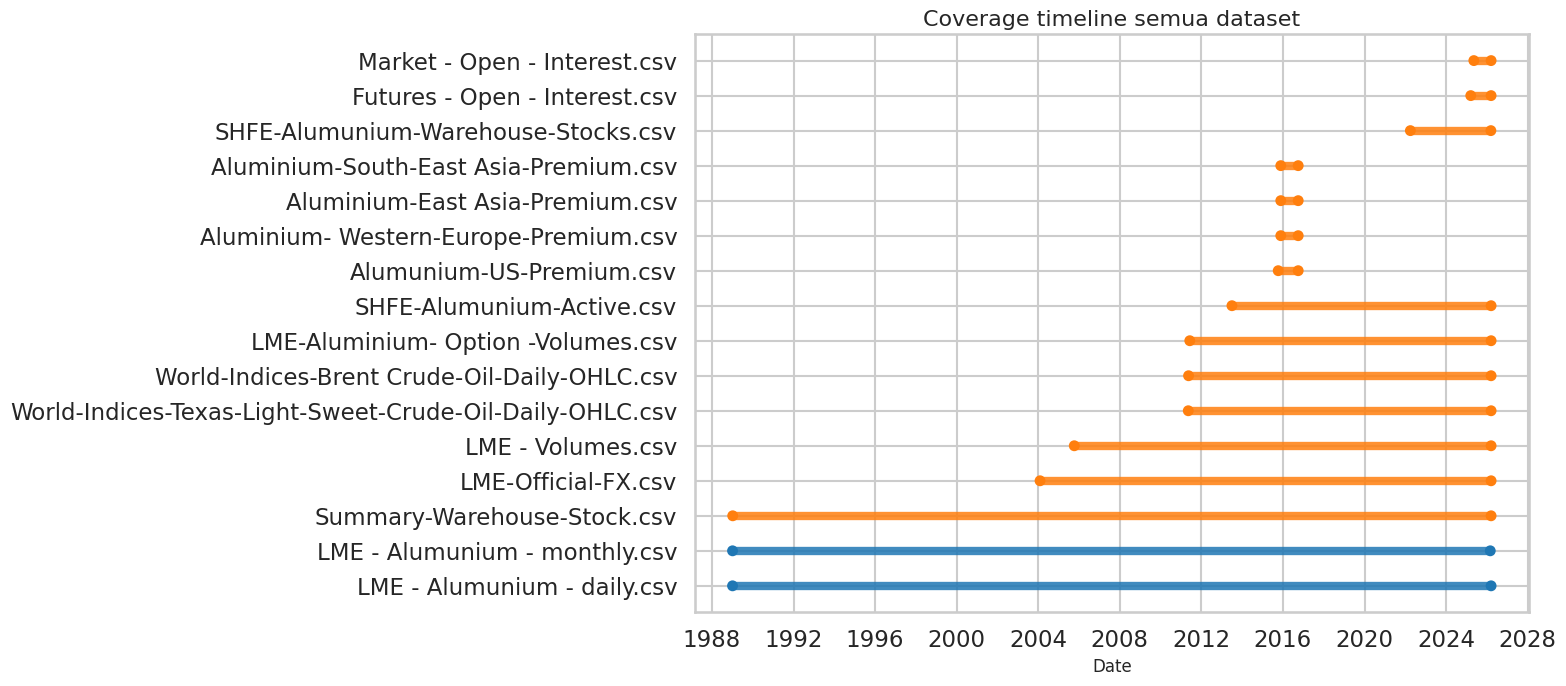

In [2]:
csv_paths = sorted(DATA_DIR.rglob("*.csv"))
inventory = pd.DataFrame([summarize_dataset(path) for path in csv_paths]).sort_values(["group", "dataset"]).reset_index(drop=True)

print(f"Total CSV datasets: {len(inventory)}")
display(inventory.groupby("group")[["dataset"]].count().rename(columns={"dataset": "dataset_count"}))
display(format_dates(inventory, ["start_date", "end_date"]))

coverage_df = inventory.dropna(subset=["start_date", "end_date"]).sort_values("start_date").reset_index(drop=True)
y = np.arange(len(coverage_df))
colors = coverage_df["group"].map({"target": "#1f77b4", "exogenous": "#ff7f0e"})

fig, ax = plt.subplots(figsize=(16, max(6, len(coverage_df) * 0.45)))
ax.hlines(y=y, xmin=coverage_df["start_date"], xmax=coverage_df["end_date"], color=colors, linewidth=6, alpha=0.85)
ax.scatter(coverage_df["start_date"], y, color=colors, s=40)
ax.scatter(coverage_df["end_date"], y, color=colors, s=40)
ax.set_yticks(y)
ax.set_yticklabels(coverage_df["dataset"])
ax.set_title("Coverage timeline semua dataset")
ax.set_xlabel("Date")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 2. Audit Awal Target Daily dan Monthly

Karena use case bisnis dan eksperimen Prophet berikutnya akan banyak bergantung pada target `daily`, bagian ini fokus pada:
- kualitas dasar target
- perilaku harga `daily`
- gambaran return harian dan volatilitas kasar

,dataset,rows,start_date,end_date,duplicate_dates,missing_cells_pct,volume_zero_pct,openinterest_zero_pct
0,daily,9370,1989-01-03,2026-03-17,0,0.02,100.0,100.0
1,monthly,447,1989-01-03,2026-03-02,0,0.00,100.0,100.0


,startdatetime,priceopen,pricehigh,pricelow,priceclose,volume,openinterest,return_pct_1d,log_return_1d,rolling_vol_22d,intraday_range_pct
0,1989-01-03,2600.0,2600.0,2600.0,2600.0,0,0,NaN,NaN,NaN,0.0
1,1989-01-04,2595.0,2595.0,2595.0,2595.0,0,0,-0.192308,-0.001925,NaN,0.0
2,1989-01-05,2502.0,2502.0,2502.0,2502.0,0,0,-3.583815,-0.036496,NaN,0.0
3,1989-01-06,2450.0,2450.0,2450.0,2450.0,0,0,-2.078337,-0.021002,NaN,0.0
4,1989-01-09,2445.0,2445.0,2445.0,2445.0,0,0,-0.204082,-0.002043,NaN,0.0


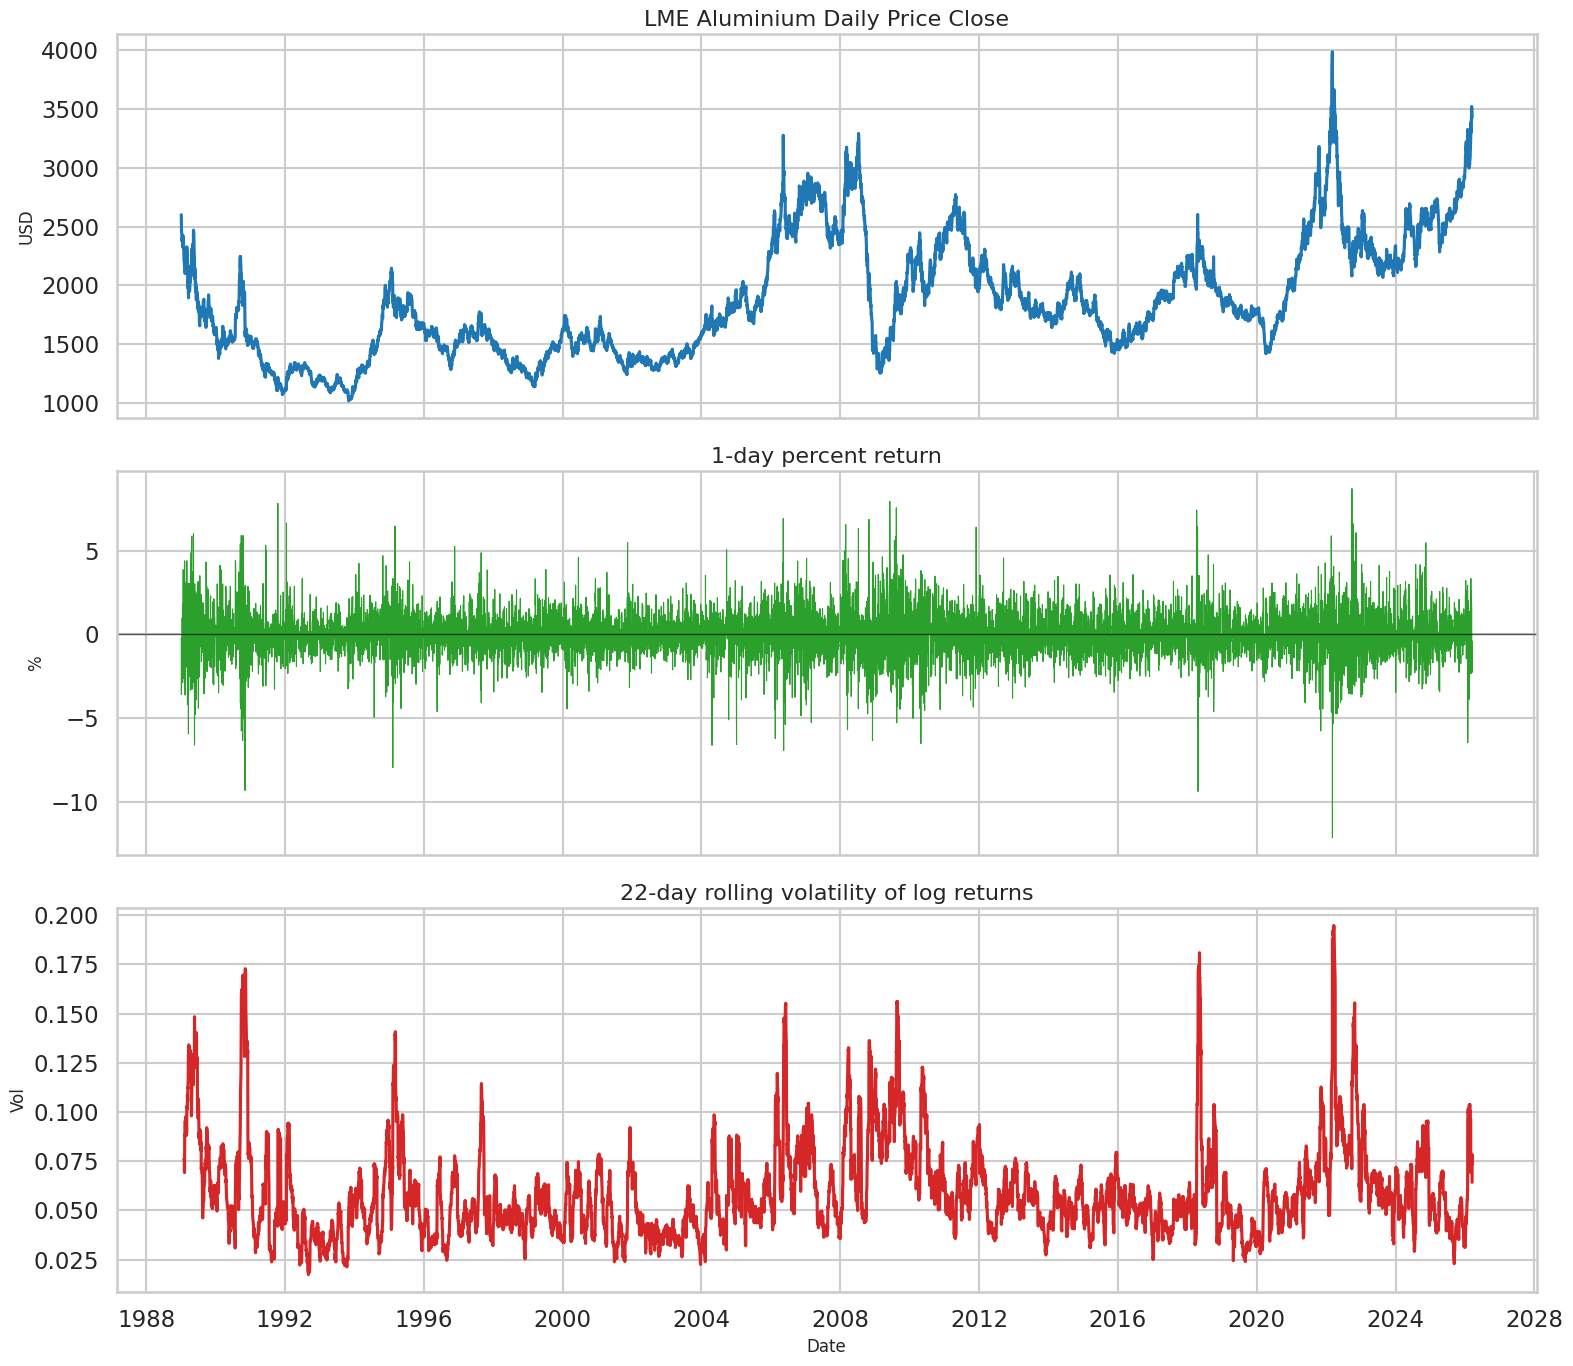

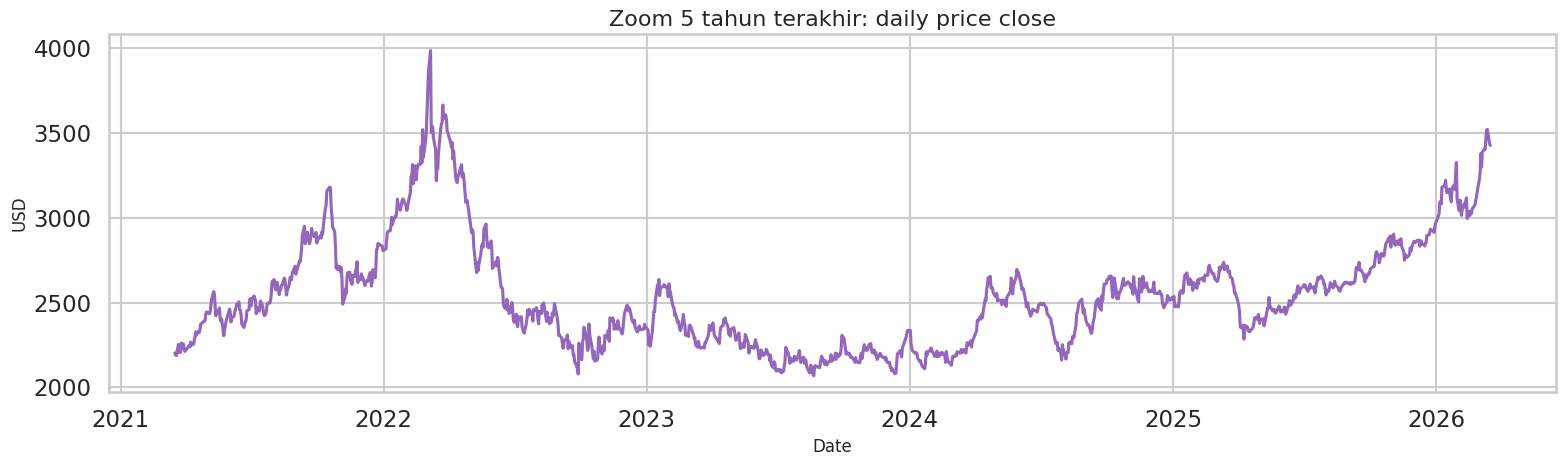

In [3]:
daily = load_csv(DATA_DIR / "LME - Alumunium - daily.csv").sort_values("startdatetime").reset_index(drop=True)
monthly = load_csv(DATA_DIR / "LME - Alumunium - monthly.csv").sort_values("startdatetime").reset_index(drop=True)

daily["return_pct_1d"] = daily["priceclose"].pct_change() * 100
daily["log_return_1d"] = np.log(daily["priceclose"]).diff()
daily["rolling_vol_22d"] = daily["log_return_1d"].rolling(22).std() * np.sqrt(22)
daily["intraday_range_pct"] = (daily["pricehigh"] - daily["pricelow"]) / daily["priceclose"].replace(0, np.nan) * 100

quality_table = pd.DataFrame(
    [
        {
            "dataset": "daily",
            "rows": len(daily),
            "start_date": daily["startdatetime"].min(),
            "end_date": daily["startdatetime"].max(),
            "duplicate_dates": int(daily["startdatetime"].duplicated().sum()),
            "missing_cells_pct": round(daily.isna().mean().mean() * 100, 2),
            "volume_zero_pct": round((daily["volume"] == 0).mean() * 100, 2),
            "openinterest_zero_pct": round((daily["openinterest"] == 0).mean() * 100, 2),
        },
        {
            "dataset": "monthly",
            "rows": len(monthly),
            "start_date": monthly["startdatetime"].min(),
            "end_date": monthly["startdatetime"].max(),
            "duplicate_dates": int(monthly["startdatetime"].duplicated().sum()),
            "missing_cells_pct": round(monthly.isna().mean().mean() * 100, 2),
            "volume_zero_pct": round((monthly["volume"] == 0).mean() * 100, 2),
            "openinterest_zero_pct": round((monthly["openinterest"] == 0).mean() * 100, 2),
        },
    ]
)

display(format_dates(quality_table, ["start_date", "end_date"]))
display(daily.head())

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

axes[0].plot(daily["startdatetime"], daily["priceclose"], color="#1f77b4")
axes[0].set_title("LME Aluminium Daily Price Close")
axes[0].set_ylabel("USD")

axes[1].plot(daily["startdatetime"], daily["return_pct_1d"], color="#2ca02c", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set_title("1-day percent return")
axes[1].set_ylabel("%")

axes[2].plot(daily["startdatetime"], daily["rolling_vol_22d"], color="#d62728")
axes[2].set_title("22-day rolling volatility of log returns")
axes[2].set_ylabel("Vol")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

recent = daily[daily["startdatetime"] >= daily["startdatetime"].max() - pd.DateOffset(years=5)]
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(recent["startdatetime"], recent["priceclose"], color="#9467bd")
ax.set_title("Zoom 5 tahun terakhir: daily price close")
ax.set_xlabel("Date")
ax.set_ylabel("USD")
plt.tight_layout()
plt.show()

## 3. Audit Kesiapan Exogenous untuk Prophet

Tidak semua exogenous otomatis layak menjadi regressor Prophet.

Untuk tahap awal, kita cek beberapa hal yang paling menentukan:
- overlap dengan target `daily`
- apakah satu tanggal hanya punya satu baris atau perlu agregasi dulu
- apakah coverage-nya cukup panjang untuk eksperimen awal
- apakah secara bisnis dan domain masuk akal sebagai sinyal pendukung

,dataset,rows,start_date,end_date,overlap_years,duplicate_dates,freq_guess,missing_cells_pct,initial_readiness
6,LME-Aluminium- Option -Volumes.csv,10000,2011-06-07,2026-03-17,14.78,6263,daily-ish,0.0,aggregate first
9,SHFE-Alumunium-Active.csv,3098,2013-07-01,2026-03-17,12.71,28,daily-ish,0.0,aggregate first
10,SHFE-Alumunium-Warehouse-Stocks.csv,10000,2022-04-01,2026-03-13,3.95,9798,weekly-ish,0.0,aggregate first
5,LME - Volumes.csv,5168,2005-10-07,2026-03-17,20.44,0,daily-ish,0.0,good candidate
7,LME-Official-FX.csv,5580,2004-02-02,2026-03-17,22.12,0,daily-ish,0.0,good candidate
11,Summary-Warehouse-Stock.csv,7939,1989-01-06,2026-03-17,37.19,0,daily-ish,0.0,good candidate
12,World-Indices-Brent Crude-Oil-Daily-OHLC.csv,3822,2011-05-16,2026-03-17,14.84,0,daily-ish,0.0,good candidate
13,World-Indices-Texas-Light-Sweet-Crude-Oil-Dail...,3837,2011-05-11,2026-03-17,14.85,0,daily-ish,0.0,good candidate
0,Aluminium- Western-Europe-Premium.csv,136,2015-11-23,2016-09-30,0.86,0,daily-ish,0.0,too short
1,Aluminium-East Asia-Premium.csv,136,2015-11-23,2016-09-30,0.86,0,daily-ish,0.0,too short


,dataset,status,why
0,Summary-Warehouse-Stock.csv,shortlist,"coverage sangat panjang, daily-compatible, ber..."
1,LME - Volumes.csv,shortlist,coverage panjang dan langsung terkait aktivita...
2,LME-Official-FX.csv,shortlist,"coverage panjang, daily-compatible, kandidat s..."
3,SHFE-Alumunium-Active.csv,shortlist,coverage cukup panjang dan relevan sebagai cro...
4,World-Indices-Brent Crude-Oil-Daily-OHLC.csv,shortlist,proxy energi/makro dengan coverage cukup panjang
5,World-Indices-Texas-Light-Sweet-Crude-Oil-Dail...,shortlist,proxy energi/makro dengan coverage cukup panjang
6,LME-Aluminium- Option -Volumes.csv,needs aggregation,"banyak baris per tanggal, perlu agregasi sebel..."
7,SHFE-Alumunium-Warehouse-Stocks.csv,needs aggregation,"banyak baris per tanggal, perlu agregasi wareh..."
8,Futures - Open - Interest.csv,watchlist,daily-compatible tetapi coverage masih sangat ...
9,Market - Open - Interest.csv,watchlist,daily-compatible tetapi coverage masih sangat ...


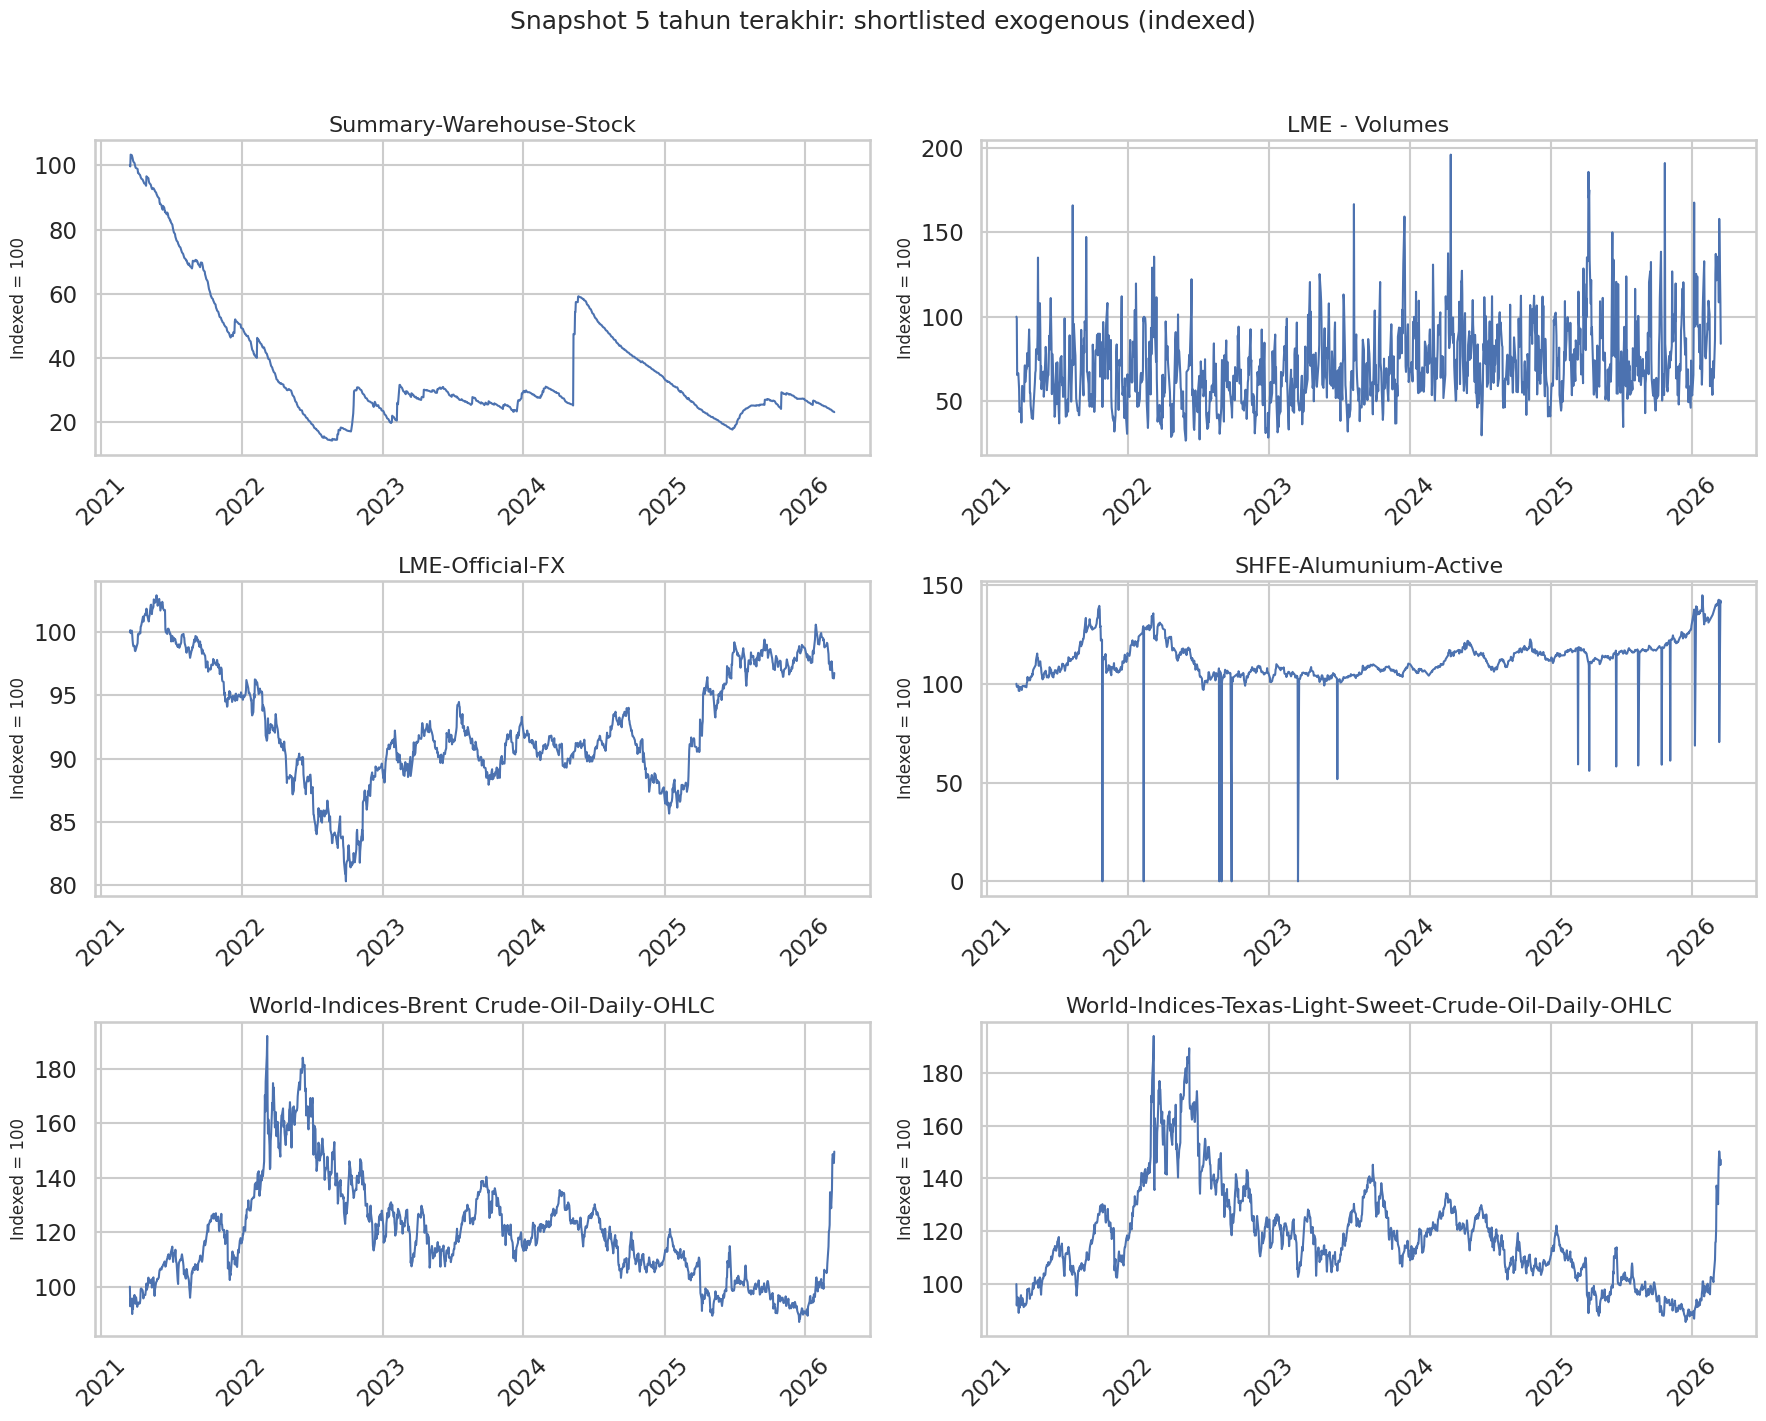

In [4]:
daily_start = daily["startdatetime"].min()
daily_end = daily["startdatetime"].max()

exog_inventory = inventory.query("group == 'exogenous'").copy()
exog_inventory["overlap_start"] = exog_inventory["start_date"].apply(lambda x: max(x, daily_start) if pd.notna(x) else pd.NaT)
exog_inventory["overlap_end"] = exog_inventory["end_date"].apply(lambda x: min(x, daily_end) if pd.notna(x) else pd.NaT)
exog_inventory["overlap_days"] = (exog_inventory["overlap_end"] - exog_inventory["overlap_start"]).dt.days + 1
exog_inventory["overlap_years"] = (exog_inventory["overlap_days"] / 365.25).round(2)
exog_inventory["one_row_per_date"] = exog_inventory["duplicate_dates"].eq(0)

def initial_readiness(row):
    if pd.isna(row["overlap_days"]) or row["overlap_days"] < 365:
        return "too short"
    if row["duplicate_dates"] > 0:
        return "aggregate first"
    if row["overlap_days"] >= 365 * 3:
        return "good candidate"
    return "watchlist"

exog_inventory["initial_readiness"] = exog_inventory.apply(initial_readiness, axis=1)

audit_cols = [
    "dataset",
    "rows",
    "start_date",
    "end_date",
    "overlap_years",
    "duplicate_dates",
    "freq_guess",
    "missing_cells_pct",
    "initial_readiness",
]
display(format_dates(exog_inventory[audit_cols].sort_values(["initial_readiness", "dataset"]), ["start_date", "end_date"]))

manual_notes = pd.DataFrame(
    [
        {"dataset": "Summary-Warehouse-Stock.csv", "status": "shortlist", "why": "coverage sangat panjang, daily-compatible, berkaitan dengan sisi supply/LME"},
        {"dataset": "LME - Volumes.csv", "status": "shortlist", "why": "coverage panjang dan langsung terkait aktivitas pasar LME"},
        {"dataset": "LME-Official-FX.csv", "status": "shortlist", "why": "coverage panjang, daily-compatible, kandidat sinyal makro/FX"},
        {"dataset": "SHFE-Alumunium-Active.csv", "status": "shortlist", "why": "coverage cukup panjang dan relevan sebagai cross-market aluminium signal"},
        {"dataset": "World-Indices-Brent Crude-Oil-Daily-OHLC.csv", "status": "shortlist", "why": "proxy energi/makro dengan coverage cukup panjang"},
        {"dataset": "World-Indices-Texas-Light-Sweet-Crude-Oil-Daily-OHLC.csv", "status": "shortlist", "why": "proxy energi/makro dengan coverage cukup panjang"},
        {"dataset": "LME-Aluminium- Option -Volumes.csv", "status": "needs aggregation", "why": "banyak baris per tanggal, perlu agregasi sebelum jadi regressor Prophet"},
        {"dataset": "SHFE-Alumunium-Warehouse-Stocks.csv", "status": "needs aggregation", "why": "banyak baris per tanggal, perlu agregasi warehouse-level ke daily total"},
        {"dataset": "Futures - Open - Interest.csv", "status": "watchlist", "why": "daily-compatible tetapi coverage masih sangat pendek"},
        {"dataset": "Market - Open - Interest.csv", "status": "watchlist", "why": "daily-compatible tetapi coverage masih sangat pendek"},
        {"dataset": "Aluminium- Western-Europe-Premium.csv", "status": "exclude for initial run", "why": "coverage sangat pendek dan historis lama"},
        {"dataset": "Aluminium-East Asia-Premium.csv", "status": "exclude for initial run", "why": "coverage sangat pendek dan historis lama"},
        {"dataset": "Aluminium-South-East Asia-Premium.csv", "status": "exclude for initial run", "why": "coverage sangat pendek dan historis lama"},
        {"dataset": "Alumunium-US-Premium.csv", "status": "exclude for initial run", "why": "coverage sangat pendek dan historis lama"},
    ]
)

display(manual_notes)

selected_specs = {
    "Summary-Warehouse-Stock.csv": ("stockclose", "sum"),
    "LME - Volumes.csv": ("yesterdayofficialusd", "sum"),
    "LME-Official-FX.csv": ("eur", "mean"),
    "SHFE-Alumunium-Active.csv": ("close", "mean"),
    "World-Indices-Brent Crude-Oil-Daily-OHLC.csv": ("priceclose", "mean"),
    "World-Indices-Texas-Light-Sweet-Crude-Oil-Daily-OHLC.csv": ("priceclose", "mean"),
}

fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=False)
axes = axes.flatten()
cutoff = daily["startdatetime"].max() - pd.DateOffset(years=5)

for ax, (filename, (value_col, agg)) in zip(axes, selected_specs.items()):
    df = load_csv(EXOG_DIR / filename)
    date_col = infer_date_col(df)
    series = df[[date_col, value_col]].dropna()
    series = series.groupby(date_col, as_index=False)[value_col].agg(agg).sort_values(date_col)
    series = series[series[date_col] >= cutoff].copy()
    if len(series) == 0:
        ax.set_visible(False)
        continue
    base_series = series[value_col].replace(0, np.nan).dropna()
    if len(base_series) == 0:
        ax.set_visible(False)
        continue
    base = base_series.iloc[0]
    series["indexed_100"] = series[value_col] / base * 100
    ax.plot(series[date_col], series["indexed_100"], linewidth=1.5)
    ax.set_title(filename.replace(".csv", ""))
    ax.set_ylabel("Indexed = 100")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(selected_specs):]:
    ax.set_visible(False)

fig.suptitle("Snapshot 5 tahun terakhir: shortlisted exogenous (indexed)", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

## 4. Working Conclusions

Gunakan notebook ini untuk menarik kesimpulan awal berikut:
- target `daily` memang cukup panjang untuk eksperimen utama
- tidak semua exogenous layak dipakai di run pertama
- beberapa dataset perlu agregasi dulu karena multi-row per tanggal
- shortlist awal regressor sebaiknya fokus pada dataset yang coverage-nya panjang dan kompatibel dengan horizon harian

Notebook setelah ini bisa difokuskan ke salah satu dari dua arah:
1. `feature engineering and dataset assembly` untuk Prophet + regressors
2. `EDA lanjutan target/regressor` yang lebih mendalam per kandidat shortlist